<a href="https://colab.research.google.com/github/diego1399y-cmd/fundamentos-programacion-DiegoFernandez/blob/main/ProyectoFinalProgramacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install ucimlrepo -q

In [4]:
from ucimlrepo import fetch_ucirepo
import pandas as pd

wine_quality = fetch_ucirepo(id=186)

# X = variables predictoras, y = variable objetivo (la nota de calidad)
X = wine_quality.data.features
y = wine_quality.data.targets

# las juntamos en un solo DataFrame para trabajar más cómodo
df = pd.concat([X, y], axis=1)
df['color'] = wine_quality.data.original['color']
df.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality,color
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


In [5]:
print(wine_quality.variables)

                    name     role         type demographic  \
0          fixed_acidity  Feature   Continuous        None   
1       volatile_acidity  Feature   Continuous        None   
2            citric_acid  Feature   Continuous        None   
3         residual_sugar  Feature   Continuous        None   
4              chlorides  Feature   Continuous        None   
5    free_sulfur_dioxide  Feature   Continuous        None   
6   total_sulfur_dioxide  Feature   Continuous        None   
7                density  Feature   Continuous        None   
8                     pH  Feature   Continuous        None   
9              sulphates  Feature   Continuous        None   
10               alcohol  Feature   Continuous        None   
11               quality   Target      Integer        None   
12                 color    Other  Categorical        None   

               description units missing_values  
0                     None  None             no  
1                     None  Non

In [6]:

print("Filas y columnas:", df.shape)
df.info()

Filas y columnas: (6497, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         6497 non-null   float64
 1   volatile_acidity      6497 non-null   float64
 2   citric_acid           6497 non-null   float64
 3   residual_sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free_sulfur_dioxide   6497 non-null   float64
 6   total_sulfur_dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  color                 6497 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


In [7]:

df.describe()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


In [8]:
df.isna().sum()

,0
fixed_acidity,0
volatile_acidity,0
citric_acid,0
residual_sugar,0
chlorides,0
free_sulfur_dioxide,0
total_sulfur_dioxide,0
density,0
pH,0
sulphates,0


In [9]:
print("Duplicados:", df.duplicated().sum())

Duplicados: 1177


In [10]:
print("Filas antes:", df.shape[0])
df = df.drop_duplicates().reset_index(drop=True)
print("Filas después:", df.shape[0])

Filas antes: 6497
Filas después: 5320


In [11]:
categorias = ['bajo' if q <= 4 else 'medio' if q <= 6 else 'alto' for q in df['quality']]
df['categoria_calidad'] = categorias
df.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality,color,categoria_calidad
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red,medio
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red,medio
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red,medio
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red,medio
4,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5,red,medio


In [12]:
conteo_manual = {}
for cat in df['categoria_calidad']:
    conteo_manual[cat] = conteo_manual.get(cat, 0) + 1

print("Conteo manual:", conteo_manual)
print("\nConteo con value_counts():")
print(df['categoria_calidad'].value_counts())

Conteo manual: {'medio': 4075, 'alto': 1009, 'bajo': 236}

Conteo con value_counts():
categoria_calidad
medio    4075
alto     1009
bajo      236
Name: count, dtype: int64


In [13]:
import numpy as np

alcohol = df['alcohol'].to_numpy()
calidad = df['quality'].to_numpy()

print("Alcohol promedio:", np.mean(alcohol))
print("Desviación estándar del alcohol:", np.std(alcohol))

## indexado booleano: alcohol promedio de los vinos de alta calidad (quality >= 7)
alcohol_alta_calidad = alcohol[calidad >= 7]
print("Alcohol promedio en vinos de calidad >= 7:", np.mean(alcohol_alta_calidad))

## comparación con los de baja calidad (quality <= 4)
alcohol_baja_calidad = alcohol[calidad <= 4]
print("Alcohol promedio en vinos de calidad <= 4:", np.mean(alcohol_baja_calidad))

Alcohol promedio: 10.549241228066728
Desviación estándar del alcohol: 1.18582146315314
Alcohol promedio en vinos de calidad >= 7: 11.57317476048563
Alcohol promedio en vinos de calidad <= 4: 10.215042372881356


In [14]:
## que variable se relaciona mas con la calidasd
correlaciones = df.corr(numeric_only=True)['quality'].sort_values(ascending=False)
print(correlaciones)

quality                 1.000000
alcohol                 0.469422
citric_acid             0.097954
free_sulfur_dioxide     0.054002
sulphates               0.041884
pH                      0.039733
total_sulfur_dioxide   -0.050296
residual_sugar         -0.056830
fixed_acidity          -0.080092
chlorides              -0.202137
volatile_acidity       -0.265205
density                -0.326434
Name: quality, dtype: float64


In [15]:
## hay diferencias entre el vino tinto y vino blanco?
df.groupby('color')[['quality', 'alcohol', 'residual_sugar']].mean()

,quality,alcohol,residual_sugar
color,,,
red,5.623252,10.432315,2.523400
white,5.854835,10.589358,5.914819


In [16]:
## como varian estas variables claves segun la categoria de calidad
df.groupby('categoria_calidad')[['alcohol', 'volatile_acidity', 'residual_sugar']].mean().sort_values('alcohol')

,alcohol,volatile_acidity,residual_sugar
categoria_calidad,,,
bajo,10.215042,0.469322,4.175424
medio,10.315063,0.349309,5.294491
alto,11.573175,0.293930,4.259118


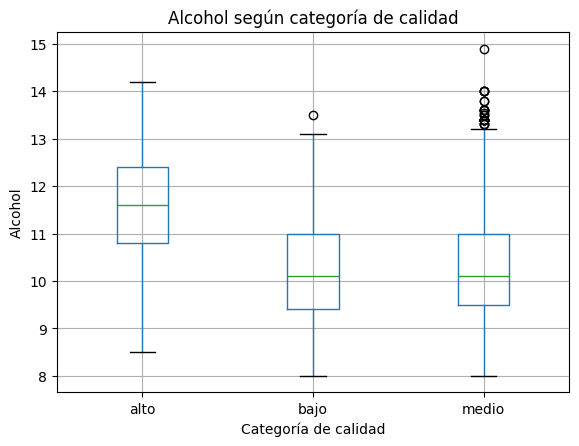

In [17]:
## Boxplot de alcohol por categoria
import matplotlib.pyplot as plt

df.boxplot(column='alcohol', by='categoria_calidad')
plt.title('Alcohol según categoría de calidad')
plt.suptitle('')
plt.xlabel('Categoría de calidad')
plt.ylabel('Alcohol')
plt.show()

Después de meterle mano al dataset, lo primero que saltó fue que había bastantes
duplicados (1177 de 6497 filas, casi el 18%), así que decidi quitarlos porque
no tenía sentido que el mismo vino contara dos o tres veces en el análisis.

De las variables que mire, el alcohol fue la que más se relacionó con la
calidad (correlación de 0.47, la más alta de todas). Esto se ve en
el boxplot, los vinos que quedaron en la categoría "alto" tienen una mediana
de alcohol  más alta (~11.6) que los de "bajo" y "medio".

También encontramos que la densidad y la acidez volátil se relacionan de
forma negativa con la calidad, o sea que entre más bajas estas dos, mejor
 puntua el vino.

Comparando tinto vs blanco, el blanco tiene muchísima más azúcar residual
(5.9 vs 2.5 en promedio) y una calidad y alcohol levemente más altos, aunque
la diferencia ahí no es tan grande como con el azúcar.

Como conclusion tenemos que el alcohol es el mejor
predictor individual de qué tan bien va a puntuar un vino, y el vino blanco
tiende a ser más dulce que el tinto por bastante margen.
